# Telecom Customer Churn Prediction

## Business Understanding

Customer churn is one of the biggest challenges faced by telecommunications companies. Losing customers leads to reduced revenue and increased acquisition costs.

The objective of this project is to analyze customer behavior and develop a machine learning model capable of predicting whether a customer is likely to churn.

Developed by : Saif Eldeen Wesam Elsayed

### Research Questions

1. What factors influence customer churn?
2. Does contract type affect churn rates?
3. Do monthly charges impact customer retention?
4. Which features are the most important predictors of churn?
5. Can machine learning accurately predict customer churn?

In [1]:
# import the most important libraries for my project 

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly_express as px


from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Data Loading

In this section, the dataset is loaded and basic information about the data is explored.

In [2]:
# Load the Data for the project 
df = pd.read_csv("churn.csv")

# show the first five rows of the Data 
df.head()

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,18,F,XW0DQ7H,Village,Platinum Membership,17-08-2017,No,xxxxxxxx,Gift Vouchers/Coupons,?,...,300.63,53005.25,17,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,32,F,5K0N3X1,City,Premium Membership,28-08-2017,?,CID21329,Gift Vouchers/Coupons,Desktop,...,306.34,12838.38,10,NaN,Yes,No,Yes,Solved,Quality Customer Care,0
2,44,F,1F2TCL3,Town,No Membership,11-11-2016,Yes,CID12313,Gift Vouchers/Coupons,Desktop,...,516.16,21027.00,22,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1
3,37,M,VJGJ33N,City,No Membership,29-10-2016,Yes,CID3793,Gift Vouchers/Coupons,Desktop,...,53.27,25239.56,6,567.66,No,Yes,Yes,Unsolved,Poor Website,1
4,31,F,SVZXCWB,City,No Membership,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,...,113.13,24483.66,16,663.06,No,Yes,Yes,Solved,Poor Website,1


In [3]:
# Show the Shape of the Data 

df.shape

(36992, 23)

In [4]:
# Show full info about the Data 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           36992 non-null  int64  
 1   gender                        36992 non-null  object 
 2   security_no                   36992 non-null  object 
 3   region_category               31564 non-null  object 
 4   membership_category           36992 non-null  object 
 5   joining_date                  36992 non-null  object 
 6   joined_through_referral       36992 non-null  object 
 7   referral_id                   36992 non-null  object 
 8   preferred_offer_types         36704 non-null  object 
 9   medium_of_operation           36992 non-null  object 
 10  internet_option               36992 non-null  object 
 11  last_visit_time               36992 non-null  object 
 12  days_since_last_login         36992 non-null  int64  
 13  a

In [5]:
# Show a full description for the Numerical Data 

df.describe()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score
count,36992.000000,36992.000000,36992.000000,36992.000000,33549.000000,36992.000000
mean,37.118161,-41.915576,243.472334,29271.194003,686.882199,0.540982
std,15.867412,228.819900,398.289149,19444.806226,194.063624,0.498324
min,10.000000,-999.000000,-2814.109110,800.460000,-760.661236,0.000000
25%,23.000000,8.000000,60.102500,14177.540000,616.150000,0.000000
50%,37.000000,12.000000,161.765000,27554.485000,697.620000,1.000000
75%,51.000000,16.000000,356.515000,40855.110000,763.950000,1.000000
max,64.000000,26.000000,3235.578521,99914.050000,2069.069761,1.000000


# Data Cleaning

This phase focuses on identifying and handling:

- Missing values
- Duplicate records
- Incorrect data types
- Inconsistent categories

In [6]:
# Replace the '?' with null values in the Data 

df.replace("?", np.nan, inplace=True)

In [7]:
# Show value_counts for the people who joined br referral 

df["joined_through_referral"].value_counts()

joined_through_referral
No     15839
Yes    15715
Name: count, dtype: int64

In [8]:
# Show the number of nulls at each columns

df.isnull().sum()

age                                0
gender                             0
security_no                        0
region_category                 5428
membership_category                0
joining_date                       0
joined_through_referral         5438
referral_id                        0
preferred_offer_types            288
medium_of_operation             5393
internet_option                    0
last_visit_time                    0
days_since_last_login              0
avg_time_spent                     0
avg_transaction_value              0
avg_frequency_login_days           0
points_in_wallet                3443
used_special_discount              0
offer_application_preference       0
past_complaint                     0
complaint_status                   0
feedback                           0
churn_risk_score                   0
dtype: int64

In [9]:
# Show the percent of null values at each columns

df.isnull().mean()*100

age                              0.000000
gender                           0.000000
security_no                      0.000000
region_category                 14.673443
membership_category              0.000000
joining_date                     0.000000
joined_through_referral         14.700476
referral_id                      0.000000
preferred_offer_types            0.778547
medium_of_operation             14.578828
internet_option                  0.000000
last_visit_time                  0.000000
days_since_last_login            0.000000
avg_time_spent                   0.000000
avg_transaction_value            0.000000
avg_frequency_login_days         0.000000
points_in_wallet                 9.307418
used_special_discount            0.000000
offer_application_preference     0.000000
past_complaint                   0.000000
complaint_status                 0.000000
feedback                         0.000000
churn_risk_score                 0.000000
dtype: float64

In [10]:
# Show if there are null values in the Data 

df.duplicated().sum()

np.int64(0)

In [11]:
# Drop the null values in the Data 

df.dropna(inplace=True)

In [12]:
# Show that null values are succesfully removed 

df.isnull().sum()

age                             0
gender                          0
security_no                     0
region_category                 0
membership_category             0
joining_date                    0
joined_through_referral         0
referral_id                     0
preferred_offer_types           0
medium_of_operation             0
internet_option                 0
last_visit_time                 0
days_since_last_login           0
avg_time_spent                  0
avg_transaction_value           0
avg_frequency_login_days        0
points_in_wallet                0
used_special_discount           0
offer_application_preference    0
past_complaint                  0
complaint_status                0
feedback                        0
churn_risk_score                0
dtype: int64

In [13]:
# Show the Data type for each column

df.dtypes

age                               int64
gender                           object
security_no                      object
region_category                  object
membership_category              object
joining_date                     object
joined_through_referral          object
referral_id                      object
preferred_offer_types            object
medium_of_operation              object
internet_option                  object
last_visit_time                  object
days_since_last_login             int64
avg_time_spent                  float64
avg_transaction_value           float64
avg_frequency_login_days         object
points_in_wallet                float64
used_special_discount            object
offer_application_preference     object
past_complaint                   object
complaint_status                 object
feedback                         object
churn_risk_score                  int64
dtype: object

In [14]:
# Make list for the Columns to convert it to Datetime

date_cols = [
    "joining_date",
    "last_visit_time"
]

In [15]:
# Make a forloop to iterate on the list to convert the columns to Datetime

for col in date_cols:
    df[col] = pd.to_datetime(
        df[col],
        errors="coerce"
    )

/var/folders/9z/gl27l3gj4sn00zjxlyrz_ffm0000gn/T/ipykernel_43288/532865398.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(


In [16]:
# (Feature Engineering) make a new column for the joining date for the year

df["joining_year"] = df["joining_date"].dt.year

In [17]:
# (Feature Engineering) make a new column for the joining date for the month

df["joining_month"] = df["joining_date"].dt.month

In [18]:
# (Feature Engineering) make a new column for the joining date for the day

df["joining_day"] = df["joining_date"].dt.day

In [19]:
# Drop the column of the "joining_date"

df.drop(
    columns=["joining_date"],
    inplace=True
)

In [20]:
# Show the unique for each object column in the data 

for col in df.select_dtypes(include="object"):
    print("\n")
    print(col)
    print(df[col].unique())



gender
['F' 'M' 'Unknown']


security_no
['1F2TCL3' 'VJGJ33N' 'SVZXCWB' ... '21KSM8Y' 'K6VTP1Z' 'LBX0GLR']


region_category
['Town' 'City' 'Village']


membership_category
['No Membership' 'Gold Membership' 'Basic Membership' 'Silver Membership'
 'Premium Membership' 'Platinum Membership']


joined_through_referral
['Yes' 'No']


referral_id
['CID12313' 'CID3793' 'xxxxxxxx' ... 'CID62597' 'CID50041' 'CID45477']


preferred_offer_types
['Gift Vouchers/Coupons' 'Credit/Debit Card Offers' 'Without Offers']


medium_of_operation
['Desktop' 'Smartphone' 'Both']


internet_option
['Wi-Fi' 'Mobile_Data' 'Fiber_Optic']


avg_frequency_login_days
['22' '6' '16' '28' '8' '33.02434314' '18' '25' '23' '3.207385793' '21'
 '7' '12' '13' 'Error' '4' '10' '27' '11' '20' '28.75639925' '14' '29' '1'
 '24' '9' '19' '3' '38.47159929' '2' '-12.71431053' '15' '5' '1.234738899'
 '17' '-13.64684955' '55.01616857' '-5.339638902' '53.5713734' '26'
 '46.43606503' '16.24538222' '-15.7259006' '38.05212158' '-4.

In [21]:
# Show the value count for each value in the gender column

df["gender"].value_counts()

gender
F          10387
M          10307
Unknown       25
Name: count, dtype: int64

In [22]:
# Remove the unknown value from the gender column 

df = df[
    df["gender"].str.lower() != "unknown"
]

In [23]:
# Check that unknown value has been removed from the gender column

df["gender"].value_counts()

gender
F    10387
M    10307
Name: count, dtype: int64

In [24]:
# Check the frequency login day data type

df["avg_frequency_login_days"].dtype

dtype('O')

In [25]:
# Convert the frequency login day from object to numeric

df["avg_frequency_login_days"] = pd.to_numeric(
    df["avg_frequency_login_days"],
    errors="coerce"
)

In [26]:
# Convert the average frequency login day that is less than zero with null value

df.loc[
    df["avg_frequency_login_days"] < 0,
    "avg_frequency_login_days"
] = np.nan

In [27]:
# Fill the null values with the median of the column of the frequency login day 

df["avg_frequency_login_days"] = (
    df["avg_frequency_login_days"]
    .fillna(df["avg_frequency_login_days"].median())
)

In [28]:
# Check the data type of the frequency login day

df["avg_frequency_login_days"].dtype

dtype('float64')

In [29]:
# Standrive the incosistence for each column

for col in df.select_dtypes(include="object"):
    
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

In [30]:
# Check the numeric columns and save them

num_cols = df.select_dtypes(
    include=np.number
).columns

num_cols

Index(['age', 'days_since_last_login', 'avg_time_spent',
       'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet',
       'churn_risk_score', 'joining_year', 'joining_month', 'joining_day'],
      dtype='object')

In [31]:
for col in num_cols:
    fig = px.box(
        df,
        x=col,
        title=col,
        width=600,   
        height=300   
    )
    
    fig.update_layout(
        title_x=0.5
    )
    
    fig.show()

In [32]:
# Keep only rows where time_spent,points_in_wallet,days_since_last_login is greater than or equal to 0
df = df[df['avg_time_spent'] >= 0]
df = df[df['points_in_wallet'] >= 0]
df = df[df['days_since_last_login'] >= 0]

In [33]:
# Function to remov the outlier values from the Data 

def remove_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[
        (df[column] >= lower)
        &
        (df[column] <= upper)
    ]

In [34]:
# Make a for loop to apply the Outlier function on the columns

for col in [
    "avg_time_spent",
    "avg_transaction_value",
    "points_in_wallet"
]:
    
    df = remove_outliers(df, col)

In [35]:
# See the value counts of the Churn score 

df["churn_risk_score"].value_counts()

churn_risk_score
1    7915
0    6457
Name: count, dtype: int64

In [36]:
# Make the values of the churn score to percentage 

round(
    df["churn_risk_score"].value_counts(normalize=True)*100,
    2
)

churn_risk_score
1    55.07
0    44.93
Name: proportion, dtype: float64

In [37]:
# Check the null values in the new columns of the Feature Engineering 

df[
    ["joining_year",
     "joining_month",
     "joining_day"]
].isnull().sum()

joining_year     8572
joining_month    8572
joining_day      8572
dtype: int64

In [38]:
# Fill the null values with the mode of the column because it's a big number of nulls in this column

for col in [
    "joining_year",
    "joining_month",
    "joining_day"
]:

    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [39]:
# Check the nulls has been filled done 

df[
    ["joining_year",
     "joining_month",
     "joining_day"]
].isnull().sum()

joining_year     0
joining_month    0
joining_day      0
dtype: int64

In [40]:
# Recheck the columns for the DATA 

df.columns

Index(['age', 'gender', 'security_no', 'region_category',
       'membership_category', 'joined_through_referral', 'referral_id',
       'preferred_offer_types', 'medium_of_operation', 'internet_option',
       'last_visit_time', 'days_since_last_login', 'avg_time_spent',
       'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet',
       'used_special_discount', 'offer_application_preference',
       'past_complaint', 'complaint_status', 'feedback', 'churn_risk_score',
       'joining_year', 'joining_month', 'joining_day'],
      dtype='object')

In [41]:
# Drop columns of the ID

drop_cols = [
    "security_no",
    "referral_id",
]

df.drop(columns=drop_cols, inplace=True)

In [42]:
# Rename the columns to make it easy to be read 

df.rename(columns={

    "region_category":"region",

    "membership_category":"membership",

    "joining_year":"join_year",

    "joining_month":"join_month",

    "joining_day":"join_day",

    "joined_through_referral":"referral",

    "preferred_offer_types":"offer_type",

    "medium_of_operation":"operation_channel",

    "internet_option":"internet",

    "avg_time_spent":"time_spent",

    "avg_transaction_value":"transaction_value",

    "avg_frequency_login_days":"login_frequency",

    "points_in_wallet":"wallet_points",

    "days_since_last_login":"last_login_days",

    "complaint_status":"complaint",

    "churn_risk_score":"churn"

}, inplace=True)

In [43]:
# Check Everythings Working Correctly

print(df.shape)

df.info()

(14372, 23)
<class 'pandas.core.frame.DataFrame'>
Index: 14372 entries, 2 to 36991
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   age                           14372 non-null  int64         
 1   gender                        14372 non-null  object        
 2   region                        14372 non-null  object        
 3   membership                    14372 non-null  object        
 4   referral                      14372 non-null  object        
 5   offer_type                    14372 non-null  object        
 6   operation_channel             14372 non-null  object        
 7   internet                      14372 non-null  object        
 8   last_visit_time               14372 non-null  datetime64[ns]
 9   last_login_days               14372 non-null  int64         
 10  time_spent                    14372 non-null  float64       
 11  transaction_value    

# Data Cleaning

Several preprocessing steps were performed to improve data quality:

1. Removed duplicate records.
2. Replaced invalid values such as '?' with missing values.
3. Handled missing numerical values using median imputation.
4. Handled missing categorical values using mode imputation.
5. Converted date columns to datetime format.
6. Extracted useful date-related features.
7. Standardized categorical text values.
8. Detected and removed extreme outliers using the IQR method.
9. Verified the final dataset for consistency and completeness.

These steps ensure that the dataset is suitable for exploratory analysis and machine learning modeling.

Additional cleaning steps were performed:

- Negative values in login frequency were identified as invalid and replaced with the median value.
- Records containing unknown gender values were removed.
- Invalid date records that generated null date features were removed.
- Column names were standardized for readability and consistency.
- Non-informative identifier columns were removed because they do not contribute to churn prediction.

These steps improved data quality and prepared the dataset for feature engineering and machine learning.

# Research Questions

The following questions will guide our analysis:

1. Does membership category affect customer churn?
2. Do customers with unresolved complaints churn more frequently?
3. Does customer engagement influence churn?
4. Does transaction value affect churn behavior?
5. Does customer feedback indicate future churn?
6. Which factors are most strongly associated with churn?

## Question 1:
### Does Membership Category Affect Churn?

In [44]:
import plotly.express as px

In [45]:
fig = px.histogram(
    df, 
    y='membership', 
    color='churn', 
    barmode='group',
    orientation='h',
    title='Membership Category vs Churn',
    width=1000,  
    height=500   
)


fig.update_layout(
    xaxis_title='Count',
    yaxis_title='Membership',
    legend_title='Churn'
)

fig.show()

#### Premium and Platinum membership customers appear less likely to churn compared to lower membership tiers.

## Question 2:
### Do Customers With Complaints Churn More?

In [46]:

fig = px.histogram(
    df, 
    x='complaint', 
    color='churn', 
    barmode='group',
    width=1000,  
    height=500  
)


fig.update_layout(
    xaxis=dict(
        tickangle=0,  
        title='Complaint'
    ),
    yaxis_title='Count',
    legend_title='Churn'
)

fig.show()

#### Customers with unresolved complaints show higher churn rates, indicating service quality is important for retention.

## Question 3:
### Does Transaction Value Affect Churn?

In [47]:

fig = px.box(
    df,
    x='churn',
    y='transaction_value',
    width=800,  
    height=500   
)

fig.update_layout(
    title='Transaction Value by Churn Status',
    xaxis_title='Churn',
    yaxis_title='Transaction Value'
)

fig.show()

#### Customers with lower transaction values appear more likely to churn.

## Question 4:
#### Does Customer Engagement Affect Churn?

In [48]:
# Check how many negative values you actually have
print(df[df['time_spent'] < 0]['time_spent'].count())

# See a quick summary of the lowest values
print(df['time_spent'].describe())

0
count    14372.000000
mean       209.618589
std        181.722856
min          1.837399
25%         64.315000
50%        152.625000
75%        301.592500
max        818.439235
Name: time_spent, dtype: float64


In [49]:

fig = px.box(
    df,
    x='churn',
    y='time_spent',
    width=800,   
    height=500   
)

fig.update_layout(
    title='Time Spent by Churn Status',
    xaxis_title='Churn',
    yaxis_title='Time Spent'
)

fig.show()

#### Customers who spend less time on the platform tend to exhibit higher churn risk.

## Question 6:
### Does Feedback Affect Churn?

In [50]:
fig = px.histogram(
    df, 
    y='feedback', 
    color='churn', 
    barmode='group',
    orientation='h',
    width=1400,  
    height=600   
)

fig.update_layout(
    title='Feedback vs Churn',
    xaxis_title='Count',
    yaxis_title='Feedback',
    legend_title='Churn',
    yaxis={'categoryorder': 'total ascending'}  
)

fig.show()

#### Negative feedback categories are strongly associated with churn.

In [51]:
# (Feature Engineering) Divide the customers into categories according to their age
df["age_group"] = pd.cut(
    df["age"],
    bins=[0,25,40,60,100],
    labels=[
        "Young",
        "Adult",
        "Middle_Aged",
        "Senior"
    ]
)

In [52]:
# Shows the value count for each age group
df["age_group"].value_counts()

age_group
Middle_Aged    5254
Young          4231
Adult          3874
Senior         1013
Name: count, dtype: int64

### Customers were grouped by age to determine whether churn behavior differs across age categories.

In [53]:
# (Feature Engineering) Divides Customers according to there activity 
df["active_customer"] = np.where(
    df["time_spent"] >
    df["time_spent"].median(),
    1,
    0
)

In [54]:
# Show the value count for each category
df["active_customer"].value_counts()

active_customer
1    7186
0    7186
Name: count, dtype: int64

### This feature distinguishes highly engaged customers from less active users.

In [55]:
fig = px.histogram(
    df, 
    x='age_group', 
    color='churn', 
    barmode='group',
    title='Age Group vs Churn',
    width=1000,  
    height=500  
)

fig.update_layout(
    xaxis_title='Age Group',
    yaxis_title='Count',
    legend_title='Churn',
    title_x=0.5  
)

fig.show()

#### The Young Customers and midaged are strongly associated with churn.

In [56]:
fig = px.histogram(
    df, 
    x='active_customer', 
    color='churn', 
    barmode='group',
    title='Active Customer vs Churn',
    width=800,   
    height=500   
)

fig.update_layout(
    xaxis_title='Active Customer',
    yaxis_title='Count',
    legend_title='Churn',
    title_x=0.5  
)

fig.show()

#### The less active Customers are associated with churn.

# Feature Selection

Feature selection helps identify the most important features affecting customer churn while reducing noise and improving model performance.

A filter-based method using correlation analysis is applied.

In [57]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.columns:

    if (
        df_encoded[col].dtype == "object"
        or str(df_encoded[col].dtype) == "category"
    ):

        df_encoded[col] = le.fit_transform(
            df_encoded[col].astype(str)
        )

In [58]:
df_encoded.select_dtypes(
    exclude=["number"]
).columns

Index(['last_visit_time'], dtype='object')

In [59]:
df_encoded = df_encoded.drop(
    columns=["last_visit_time"]
)

In [60]:
# Show a correlation between the churn and the other columns

corr = (
    df_encoded.corr()["churn"]
    .sort_values(key=abs, ascending=False)
)

corr

churn                           1.000000
wallet_points                  -0.539484
membership                     -0.455188
feedback                       -0.178768
transaction_value              -0.134584
login_frequency                 0.122052
operation_channel               0.032483
referral                        0.029311
time_spent                     -0.026943
offer_type                      0.024972
join_year                       0.024195
active_customer                -0.023360
offer_application_preference   -0.021433
last_login_days                 0.019154
region                         -0.018819
used_special_discount          -0.007161
internet                       -0.006290
past_complaint                  0.004985
age_group                      -0.003424
gender                         -0.003372
complaint                      -0.003167
join_month                     -0.001899
age                            -0.001601
join_day                        0.001353
Name: churn, dty

In [61]:
df_encoded.select_dtypes(
    exclude=["number"]
).columns

Index([], dtype='object')

In [62]:
X = df_encoded.drop("churn", axis=1)
y = df_encoded["churn"]

# Train-Test Split

The dataset is split into training and testing sets. The training set is used to train the models, while the testing set is used to evaluate their performance on unseen data.

In [63]:
# Split the Data into train and test 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [64]:
print(X_train.shape)
print(X_test.shape)

(11497, 23)
(2875, 23)


# Feature Scaling

Feature scaling ensures that numerical features have comparable ranges, improving the performance of distance-based and linear models.

In [65]:
# Scaling the Data to be in comparable range
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model 1: Logistic Regression

In [66]:
# Test the LogisticRegression Model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [67]:
# Getting the model Performance

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall   :", recall_score(y_test, pred_lr))
print("F1 Score :", f1_score(y_test, pred_lr))

Accuracy : 0.833391304347826
Precision: 0.8471698113207548
Recall   : 0.8509159823120657
F1 Score : 0.8490387645761109


## Model 2: Random Forest

In [68]:
# Test the RandomForest Model

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [69]:
# Getting the model Performance

print("Accuracy :", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall   :", recall_score(y_test, pred_rf))
print("F1 Score :", f1_score(y_test, pred_rf))

Accuracy : 0.9478260869565217
Precision: 0.950345694531741
Recall   : 0.9551484523057486
F1 Score : 0.9527410207939508


## Model 3: Gradient Boosting

In [70]:
# Test the Gradient Boosting Model


from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

In [71]:
# Getting the model Performance

print("Accuracy :", accuracy_score(y_test, pred_gb))
print("Precision:", precision_score(y_test, pred_gb))
print("Recall   :", recall_score(y_test, pred_gb))
print("F1 Score :", f1_score(y_test, pred_gb))

Accuracy : 0.953391304347826
Precision: 0.963531669865643
Recall   : 0.9513581806696146
F1 Score : 0.9574062301335029


## Compare Models

In [72]:
# Testing and Comparing Betweenn the models 

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_gb)
    ],
    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_gb)
    ],
    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_gb)
    ],
    "F1": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_gb)
    ]
})

results.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
2,Gradient Boosting,0.953391,0.963532,0.951358,0.957406
1,Random Forest,0.947826,0.950346,0.955148,0.952741
0,Logistic Regression,0.833391,0.847170,0.850916,0.849039


# Hyperparameter Tuning

GridSearchCV is used to optimize the Random Forest model by testing different combinations of parameters.

In [73]:
# Use the hyperparameter tuning to increase the performance of the model 

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [74]:
# Printing the best parameters
print(grid.best_params_)

{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}


In [75]:
best_model = grid.best_estimator_

In [76]:
# Save the final model after using the best parameters 
final_pred = best_model.predict(X_test)

print(classification_report(
    y_test,
    final_pred
))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      1292
           1       0.95      0.96      0.95      1583

    accuracy                           0.95      2875
   macro avg       0.95      0.95      0.95      2875
weighted avg       0.95      0.95      0.95      2875



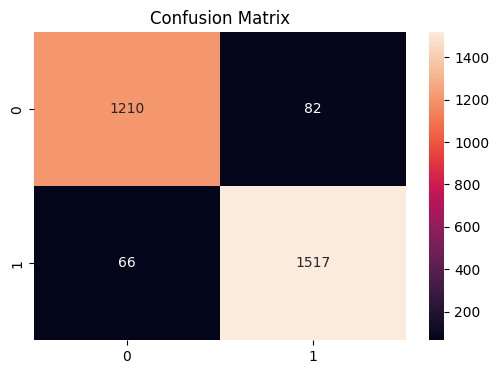

In [77]:
# Showing the confusion_matrix for the model

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    final_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.show()

In [78]:
# Saving the model and the Scalar for the Project 
import joblib

joblib.dump(
    best_model,
    "churn_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']